In [10]:

import sys
sys.path.append("../")

import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import dense_to_sparse, to_networkx
from torch_geometric.data import Data
from torch_geometric.explain import Explainer, GNNExplainer
import importlib
importlib.reload(GCN)

<module 'GCN' from '/home/petedowney/github/CrystalDefects/visulization/../GCN.py'>

# GNN Heat Map Visualizations

This notebook generates heat map visualizations for a Graph Neural Network using GNN Explainer.

- **Node Importance Heat Map**: Shows the importance of each node in the graph for the model's prediction.
- **Edge Importance Heat Map**: Shows the importance of each edge in the graph.

The model is loaded from `GCN.py` and trained weights, and explanations are generated for a sample graph from the validation set.

/tmp/ipykernel_6447/2676163310.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../models/model_{label1}_{label2}{version}.pt', map_lo

GraphConv(
  (GCN1): GATConv(20, 20, heads=6)
  (GCN2): GATConv(120, 20, heads=3)
  (linear): Linear(in_features=900, out_features=140, bias=True)
  (linear2): Linear(in_features=140, out_features=20, bias=True)
  (linear3): Linear(in_features=20, out_features=1, bias=True)
  (loss): MSELoss()
  (test): Linear(in_features=1, out_features=1, bias=True)
)


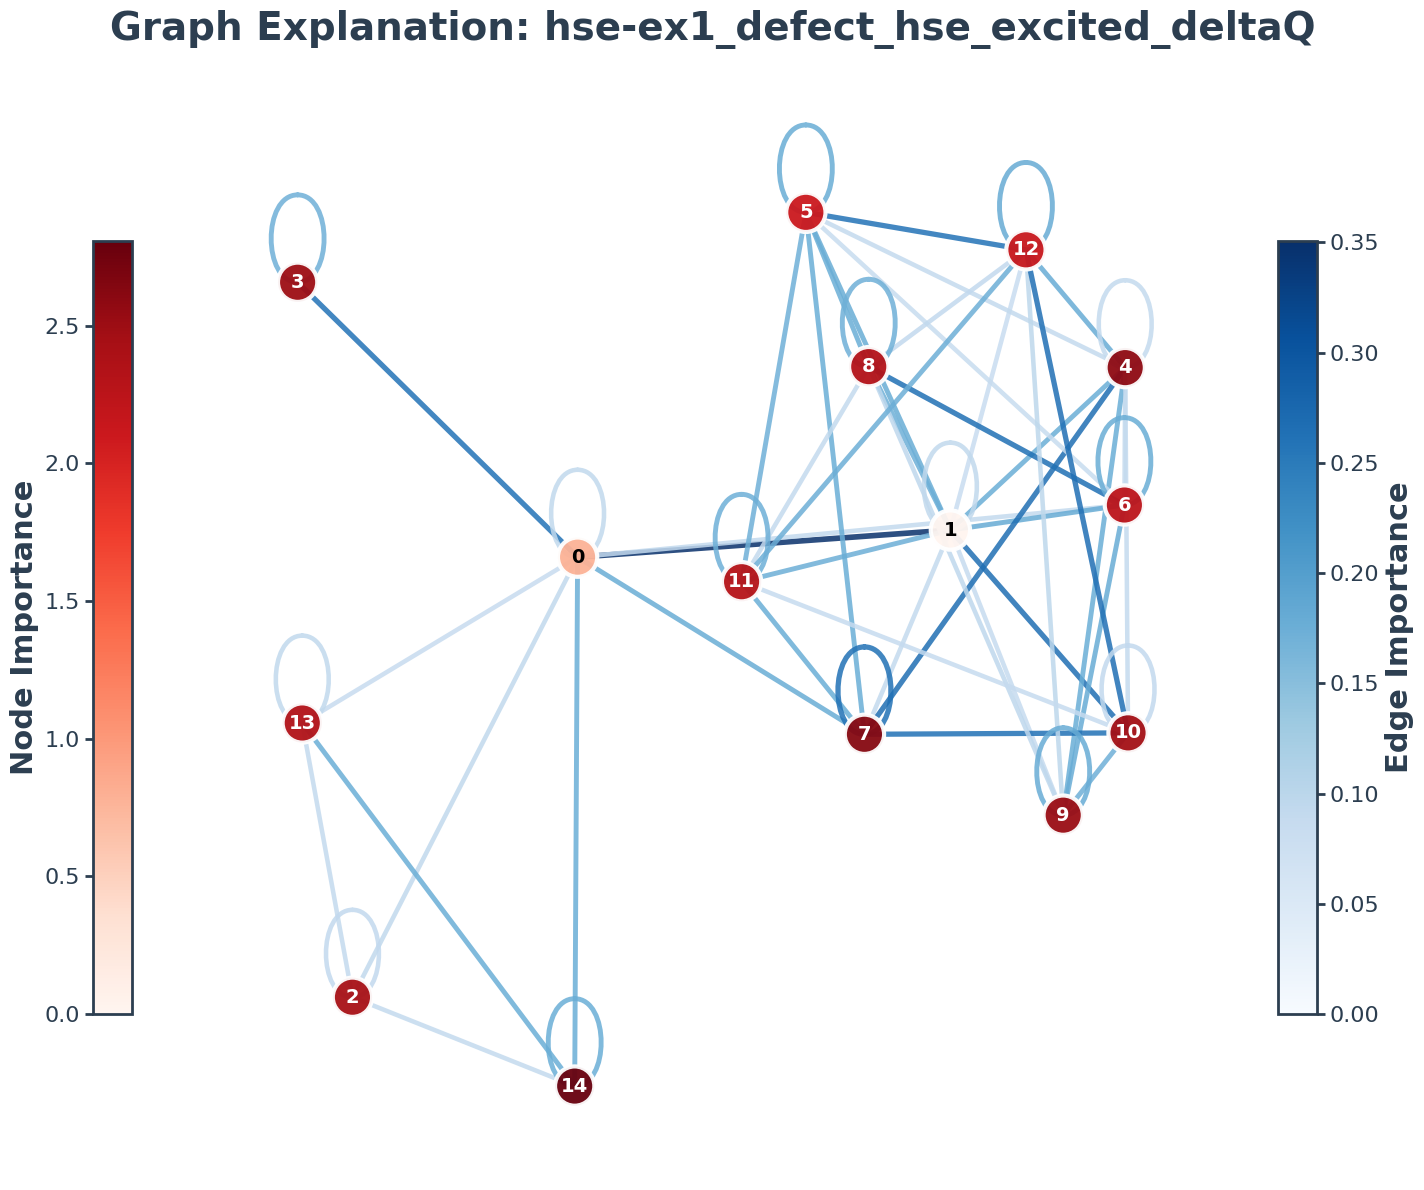

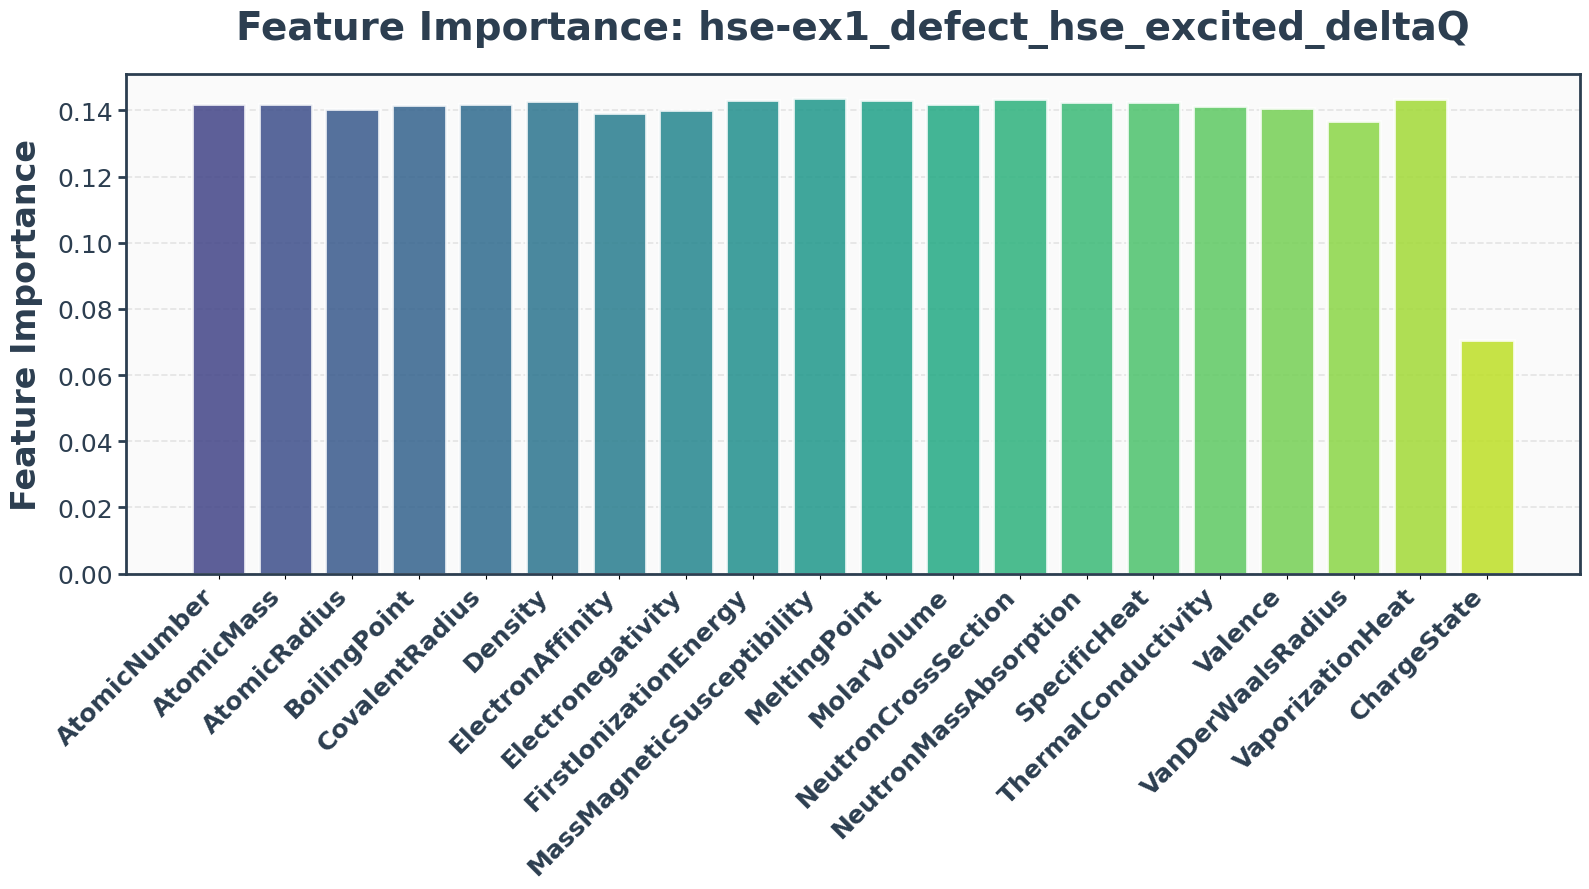

In [12]:


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def heat_map(label1, label2, version, num_samples=10):
  

    # Load data
    data_x = np.load(f'../filtered_data/{label1}_{label2}_X_val.npy')
    data_adj = np.load(f'../filtered_data/{label1}_{label2}_adj_val.npy')
    data_y = np.load(f'../filtered_data/{label1}_{label2}_y_val.npy')

    # Convert to tensors
    X_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
    adj_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
    y_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

    # Create dataset
    dataset = GCN.InterpreterDataset(X_tensor, adj_tensor, y_tensor)
    
    # Use a subset of samples (limit to available samples)
    num_samples = min(num_samples, len(dataset))

    # Load model
    model = GCN.GraphConv(20, 0.001).to(device)
    model.load_state_dict(torch.load(f'../models/model_{label1}_{label2}{version}.pt', map_location=device))
    model.eval()


    # Set up GNN Explainer
    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',
            task_level='graph',  # since it's graph-level prediction
            return_type='raw',
        ),
    )

    print(explainer.model)

    

    # Generate explanations for multiple samples and average them
    # Use first sample's graph structure for all explanations to ensure consistency
    first_data = dataset[0]
    first_data.batch = torch.zeros(first_data.x.size(0), dtype=torch.long, device=device)
    
    node_masks = []
    edge_masks = []
    
    for i in range(num_samples):
        # Run explanation on the same graph structure but different samples
        data = dataset[i]
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        # Use the graph structure from first sample for consistency
        explanation = explainer(data.x, first_data.edge_index, edge_weight=first_data.edge_weight, batch=data.batch)
        node_masks.append(explanation.node_mask.cpu().numpy())
        edge_masks.append(explanation.edge_mask.cpu().numpy())
    
    # Average the masks across all samples
    avg_node_mask = np.mean(np.array(node_masks), axis=0)
    avg_edge_mask = np.mean(np.array(edge_masks), axis=0)
    
    # Use the first sample's graph structure for visualization
    data = first_data
    G = to_networkx(data, to_undirected=True)
    
    # Compute node importance as sum of absolute mask values per node
    node_importance = np.sum(np.abs(avg_node_mask), axis=1)

    # Normalize for coloring
    node_importance_norm = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min())

    pos = nx.spring_layout(G, seed=42, k=1.6)  # Adjust k for spacing
    # Visualize edge importance
    edge_mask = avg_edge_mask

    edges = list(G.edges())
    edge_colors = [edge_mask[i] for i in range(len(edges))]
    edge_widths = [3 + 3 * edge_mask[i] for i in range(len(edges))]  # Vary width based on importance

    # Combined Node and Edge Importance in One Graph - Enhanced for poster
    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')

    # Draw edges first with importance-based colors and widths
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, edge_cmap=plt.cm.Blues, 
                          width=edge_widths, alpha=0.85, edge_vmin=0)

    # Draw nodes with importance-based colors and enhanced styling
    nx.draw_networkx_nodes(G, pos, node_color=node_importance_norm, cmap=plt.cm.Reds, 
                          node_size=800, alpha=0.95, vmin=0, 
                          edgecolors='white', linewidths=3)

    # Draw labels with contrasting colors
    labels = {node: str(node) for node in G.nodes()}
    label_colors = {node: 'white' if node_importance_norm[node] > 0.5 else 'black' for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_color=label_colors, 
                           font_size=14, font_weight='bold')

    plt.title(f'Graph Explanation: {label1}_{label2}', fontsize=28, 
             fontweight='bold', pad=25, color='#2C3E50')

    # Add colorbars with enhanced styling
    # Node colorbar
    sm_node = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                                   norm=plt.Normalize(vmin=0, vmax=node_importance.max()))
    sm_node.set_array([])
    cbar_node = plt.colorbar(sm_node, ax=plt.gca(), shrink=0.7, location='left', pad=0.05)
    cbar_node.set_label('Node Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_node.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_node.outline.set_edgecolor('#2C3E50')
    cbar_node.outline.set_linewidth(2)

    # Edge colorbar
    sm_edge = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                                   norm=plt.Normalize(vmin=0, vmax=edge_mask.max()))
    sm_edge.set_array([])
    cbar_edge = plt.colorbar(sm_edge, ax=plt.gca(), shrink=0.7, location='right', pad=0.05)
    cbar_edge.set_label('Edge Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_edge.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_edge.outline.set_edgecolor('#2C3E50')
    cbar_edge.outline.set_linewidth(2)

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../pictures/{label1}_{label2}/graph_map_{version}.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    plt.show()

    # Heatmap for Node Feature Importance
    # Read feature labels from properties.txt
    with open('../properties.txt', 'r') as f:
        lines = f.readlines()
        feature_labels = [line.split(',')[0] for line in lines[:20]]  # First 20 properties

    feature_labels = feature_labels[1:]
    feature_labels = np.append(feature_labels, 'ChargeState')

    # Average feature importance across all samples and all nodes
    avg_node_feat_mask = np.mean(avg_node_mask, axis=0)

    # Enhanced feature importance bar plot
    fig, ax = plt.subplots(figsize=(16, 9))
    fig.patch.set_facecolor('white')
    
    # Create color gradient
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(avg_node_feat_mask)))
    bars = ax.bar(range(len(avg_node_feat_mask)), avg_node_feat_mask, color=colors, 
                  alpha=0.85, edgecolor='white', linewidth=2, width=0.8)
    
    ax.set_ylabel('Feature Importance', fontsize=24, fontweight='bold', 
                  color='#2C3E50', labelpad=10)
    ax.set_title(f'Feature Importance: {label1}_{label2}', 
                fontsize=28, fontweight='bold', pad=25, color='#2C3E50')
    ax.set_xticks(range(len(avg_node_feat_mask)))
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=18, 
                       fontweight='bold', color='#2C3E50')
    
    # Enhanced grid and styling
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.2, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=18, colors='#2C3E50', width=2, length=6)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.savefig(f'../pictures/{label1}_{label2}/node_map_{version}.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    plt.show()


labels = [      
# ('pbe-gs', 'defect_initial_pbe_deltaQ', '3.0'),
# ('pbe-gs', 'defect_initial_pbe_deltaR', '3.0'), 
# ('pbe-gs', 'defect_electron_affinity', '3.0'),
# ('pbe-gs', 'defect_cbm-vbm_energy', '3.0')
# ('hse-gs', 'defect_total_energy', '2.0'),
# ('hse-gs', 'defect_lvl_tdm', '2.0'),
# ('hse-gs', 'defect_fermi_energy', '2.0'),
# ('hse-ex1', 'defect_zero_phonon_line', '2.0'),
('hse-ex1', 'defect_hse_excited_deltaQ', '4.0')
]

for label1, label2, version in labels:
    heat_map(label1, label2, version)




/tmp/ipykernel_3551/4259861506.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

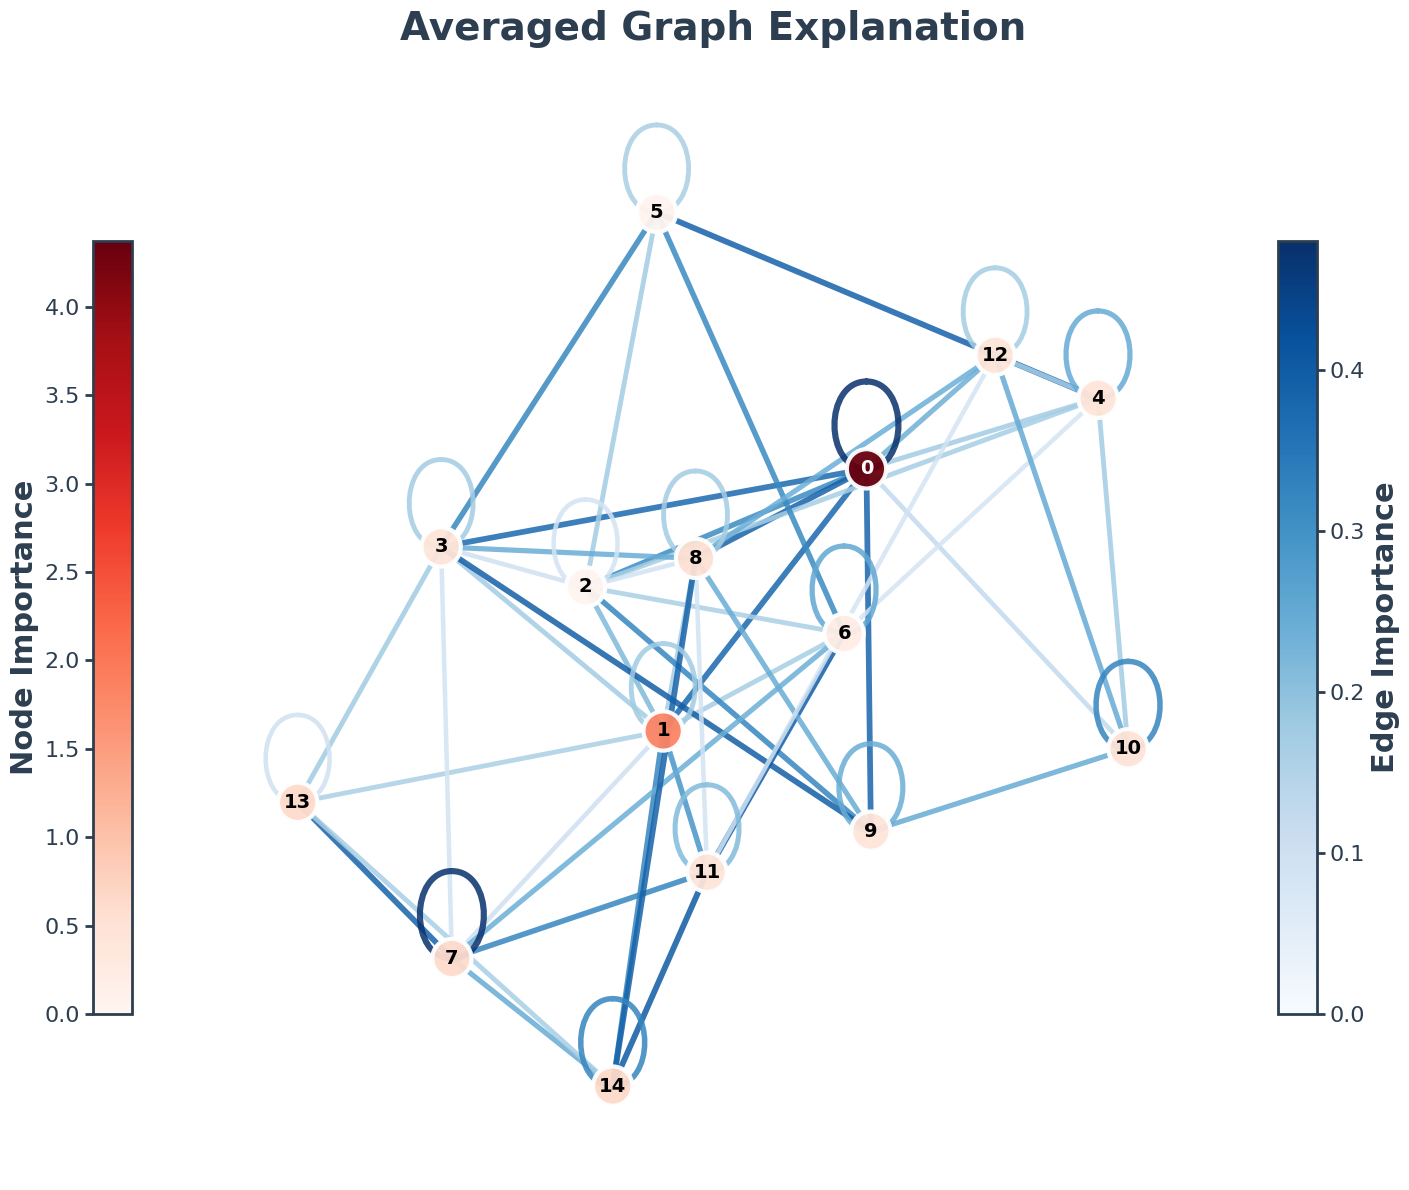

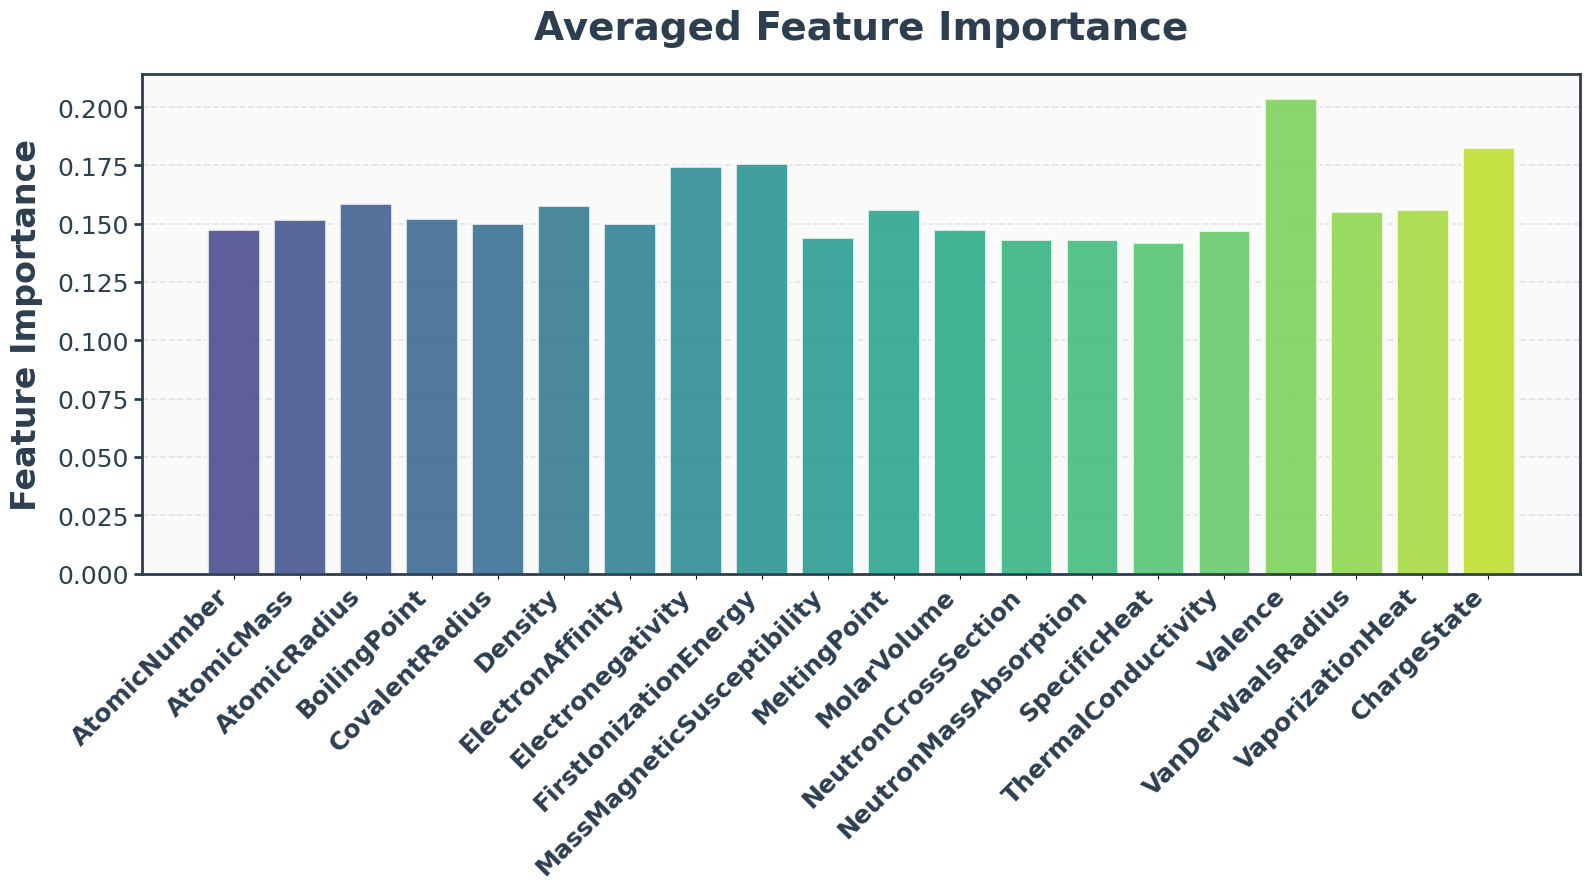

In [ ]:
def averaged_graph(data_list):

    # Use data from the first model
    first_label1, first_label2, first_version = data_list[0]
    data_x = np.load(f'filtered_data/{first_label1}_{first_label2}_X_val.npy')
    data_adj = np.load(f'filtered_data/{first_label1}_{first_label2}_adj_val.npy')
    data_y = np.load(f'filtered_data/{first_label1}_{first_label2}_y_val.npy')

    # Take first sample
    X = torch.tensor(data_x[0], dtype=torch.float).to(device)
    adj = torch.tensor(data_adj[0], dtype=torch.float).to(device)
    y = torch.tensor(data_y[0], dtype=torch.float).to(device)

    # Convert to PyG data
    edge_index, edge_weight = dense_to_sparse(adj[:GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
    data = Data(x=X[:GCN.GRAPH_SIZE], edge_index=edge_index, edge_weight=edge_weight, y=y)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)

    node_masks = []
    edge_masks = []
    node_feat_masks = []

    for (label1, label2, version) in data_list:
        # Load model
        model = GCN.GraphConv(20, 0.001).to(device)
        model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()

        # Set up GNN Explainer
        explainer = Explainer(
            model=model,
            algorithm=GNNExplainer(epochs=200),
            explanation_type='model',
            node_mask_type='attributes',
            edge_mask_type='object',
            model_config=dict(
                mode='regression',
                task_level='graph',  # since it's graph-level prediction
                return_type='raw',
            ),
        )

        # Generate explanation for the graph
        explanation = explainer(data.x, data.edge_index, edge_weight=data.edge_weight, batch=data.batch)

        node_mask = explanation.node_mask.cpu().numpy()
        edge_mask = explanation.edge_mask.cpu().numpy()
        node_feat_mask = np.mean(explanation.node_mask.cpu().numpy(), axis=0)

        node_masks.append(node_mask)
        edge_masks.append(edge_mask)
        node_feat_masks.append(node_feat_mask)
    
    # Average masks
    avg_node_map = np.mean(np.array(node_masks), axis=0)
    avg_edge_map = np.mean(np.array(edge_masks), axis=0)
    avg_node_feat_map = np.mean(np.array(node_feat_masks), axis=0)

    G = to_networkx(data, to_undirected=True)

    # Compute node importance as sum of absolute mask values per node
    node_importance = np.sum(np.abs(avg_node_map), axis=1)

    # Normalize for coloring
    node_importance_norm = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min())

    pos = nx.spring_layout(G, seed=42, k=1.6)  # Adjust k for spacing
    # Visualize edge importance
    edge_mask = avg_edge_map

    edges = list(G.edges())
    edge_colors = [edge_mask[i] for i in range(len(edges))]
    edge_widths = [3 + 3 * edge_mask[i] for i in range(len(edges))]  # Vary width based on importance

    # Combined Node and Edge Importance in One Graph - Enhanced for poster
    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')

    # Draw edges first with importance-based colors and widths
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, edge_cmap=plt.cm.Blues, 
                          width=edge_widths, alpha=0.85, edge_vmin=0)

    # Draw nodes with importance-based colors and enhanced styling
    nx.draw_networkx_nodes(G, pos, node_color=node_importance_norm, cmap=plt.cm.Reds, 
                          node_size=800, alpha=0.95, vmin=0,
                          edgecolors='white', linewidths=3)

    # Draw labels with contrasting colors
    labels = {node: str(node) for node in G.nodes()}
    label_colors = {node: 'white' if node_importance_norm[node] > 0.5 else 'black' for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_color=label_colors, 
                           font_size=14, font_weight='bold')

    plt.title('Averaged Graph Explanation', fontsize=28, 
             fontweight='bold', pad=25, color='#2C3E50')

    # Add colorbars with enhanced styling
    # Node colorbar
    sm_node = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                                   norm=plt.Normalize(vmin=0, vmax=node_importance.max()))
    sm_node.set_array([])
    cbar_node = plt.colorbar(sm_node, ax=plt.gca(), shrink=0.7, location='left', pad=0.05)
    cbar_node.set_label('Node Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_node.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_node.outline.set_edgecolor('#2C3E50')
    cbar_node.outline.set_linewidth(2)

    # Edge colorbar
    sm_edge = plt.cm.ScalarMappable(cmap=plt.cm.Blues, 
                                   norm=plt.Normalize(vmin=0, vmax=edge_mask.max()))
    sm_edge.set_array([])
    cbar_edge = plt.colorbar(sm_edge, ax=plt.gca(), shrink=0.7, location='right', pad=0.05)
    cbar_edge.set_label('Edge Importance', fontsize=22, fontweight='bold', color='#2C3E50')
    cbar_edge.ax.tick_params(labelsize=16, colors='#2C3E50', width=2, length=6)
    cbar_edge.outline.set_edgecolor('#2C3E50')
    cbar_edge.outline.set_linewidth(2)

    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'../pictures/poster/averaged_graph_map.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    plt.show()

    # Heatmap for Averaged Node 0 Feature Vector
    # Read feature labels from properties.txt
    with open('properties.txt', 'r') as f:
        lines = f.readlines()
        feature_labels = [line.split(',')[0] for line in lines[:20]]  # First 20 properties

    feature_labels = feature_labels[1:]
    feature_labels = np.append(feature_labels, 'ChargeState')

    # Enhanced averaged feature importance bar plot
    fig, ax = plt.subplots(figsize=(16, 9))
    fig.patch.set_facecolor('white')
    
    # Create color gradient
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(avg_node_feat_map)))
    bars = ax.bar(range(len(avg_node_feat_map)), avg_node_feat_map, color=colors, 
                  alpha=0.85, edgecolor='white', linewidth=2, width=0.8)
    
    ax.set_ylabel('Feature Importance', fontsize=24, fontweight='bold', 
                  color='#2C3E50', labelpad=10)
    ax.set_title('Averaged Feature Importance', fontsize=28, 
                fontweight='bold', pad=25, color='#2C3E50')
    ax.set_xticks(range(len(avg_node_feat_map)))
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=18, 
                       fontweight='bold', color='#2C3E50')
    
    # Enhanced grid and styling
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.2, zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=18, colors='#2C3E50', width=2, length=6)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.savefig(f'pictures/poster/averaged_node_map.png', dpi=300, 
               bbox_inches='tight', facecolor='white')
    plt.show()


labels = [
            ('pbe-gs', 'defect_ionization_energy', '4.0'), 
            ('pbe-gs', 'defect_initial_pbe_deltaQ', '4.0'),
            ('pbe-gs', 'defect_initial_pbe_deltaR', '4.0'), 
            ('pbe-gs', 'defect_electron_affinity', '4.0'),
            ('pbe-gs', 'defect_cbm-vbm_energy', '4.0'),
            ('hse-gs', 'defect_total_energy', '4.0'),
            ('hse-gs', 'defect_lvl_tdm', '4.0'),
            ('hse-gs', 'defect_fermi_energy', '4.0'),
            ('hse-gs', 'defect_vbm_energy', '4.0'),
            ('hse-ex1', 'defect_zero_phonon_line', '4.0'),
            ('hse-ex1', 'defect_hse_excited_deltaQ', '4.0')
            ]

averaged_graph(labels)

